In [1]:
import sys
sys.path.append("..")  # Adds higher directory to python modules path.

from src import IOFunctions
from src import CalibrationFunctions

IO = IOFunctions.IO_Functions()

from src import MaskFunctions
Mask = MaskFunctions.Mask_Functions()

from src import PlottingFunctions

import os 
import matplotlib.pyplot as plt
import numpy as np
plotter = PlottingFunctions.Plotter()

In [2]:
directory = r'/media/jbeckwith/Ezra Seagat/JSB/20250327 Ximea calibration/'

In [25]:
data_L.shape

(1544, 2064)

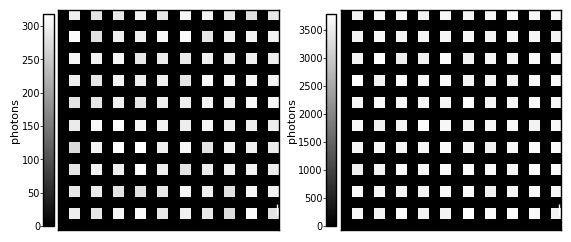

In [3]:
colour = 'R'
file_L = 'Intensity_01_1_MMStack_Default_1.ome.tif'
file_H = 'Intensity_06_1_MMStack_Default_1.ome.tif'

data_L = IO.read_tiff(os.path.join(directory, colour, file_L), dtype=np.uint16, frame=1)
data_H = IO.read_tiff(os.path.join(directory, colour, file_H), dtype=np.uint16, frame=1)
mosaic_unit = np.array([["B", "G"], ["G", "R"]])
masks = Mask.get_masks(
            mosaic_unit=mosaic_unit, size_x=data_L.shape[0], size_y=data_L.shape[1]
        )

fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

axs[0] = plotter.image_plot(axs=axs[0], data=np.array(data_L*masks['R'])[:20, :20], scalebarlabel='', scalebarsize=0)
axs[1] = plotter.image_plot(axs=axs[1], data=np.array(data_H*masks['R'])[:20, :20], scalebarlabel='', scalebarsize=0)

In [4]:
C_F = CalibrationFunctions.Calibration_Functions(mosaic_unit=mosaic_unit)
offset, variance, gain, readnoise, rqe = C_F.calibrate_multicolour_camera(directory, imtype=".tif")

In [21]:
folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/Ximea_Calibration/'